# Project 3 - 2026

Work in groups of 2-5. Prepare ~10 slides where one slide describes your setup and analysis, main results, challenges/suprises and take-home message.

Everyone should do the first part of the project. You will be allocated one of the three themes for part 2 - check announcements on canvas to see which theme is allocated to your group.

You will be working with the Cats and Dogs data set and/or the MNIST data set.

For all tasks, you have to repeat the exercise in order to be able to draw conclusions. That is, one single run of a data analysis task or simulation has very limited information so repeat a few times to ensure you are not drawing conclusions based on a random "fluke". 

The most structured way to do this is Nested CV. That is, an outer K-fold split into training and test and an inner CV-loop for tuning models. However, you can also use repeated random splits into training and testing instead of CV. The benefit of using CV is that the correlation between the outer splits, but a large number of random splits might be more beneficial if you want to compare many models in an outer loop. 


In [54]:
# 

# First the cats and dogs data...
import pandas as pd 

PATHIM = "cnd_large//cnd_large//images.csv" 
PATHLB = "cnd_large//cnd_large//labels.csv"

images = pd.read_csv(PATHIM, sep=",", index_col=0)
labels = pd.read_csv(PATHLB, sep=",", index_col=0)

labels = labels.rename(columns={"0":"label"})

# Check sizes
print(f"'images' size: {images.shape}")
print(f"'labels' size: {labels.shape}")

# Number of classes:
print(f"Classes {labels['label'].unique()}")

'images' size: (10000, 4096)
'labels' size: (10000, 1)
Classes [0 1]


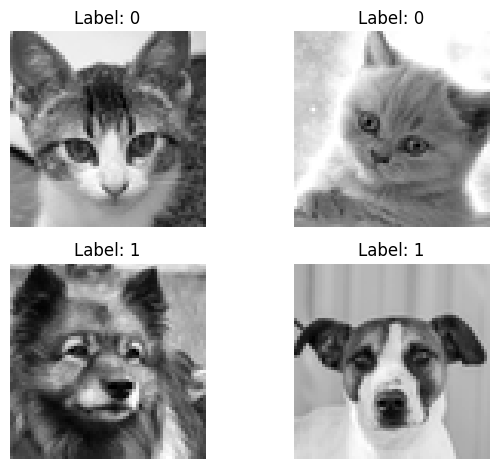

In [55]:
import matplotlib.pyplot as plt
import numpy as np

images = np.array(images)
labels = np.array(labels).ravel()

# Visualize some images (take two from each class):
catidx = np.where(labels == 0)[0]
dogidx = np.where(labels == 1)[0]

n_samples = 2

catsample = np.random.choice(catidx, size = n_samples, replace = False)
dogsample = np.random.choice(dogidx, size = n_samples, replace = False)

idx = np.concatenate([catsample, dogsample])
images_sub = images[idx]
labels_sub = labels[idx]

fig, axes = plt.subplots(2, 2)

for i, ax in enumerate(axes.ravel()):
    img = images_sub[i].reshape(64,64)
    ax.imshow(img, cmap="gray")
    ax.set_title(f"Label: {labels_sub[i]}")
    ax.axis("off")

plt.tight_layout()

# Part 1

*Everyone should do this task.*

For the first part, use the large cats and dogs dataset in order to investigate the effects of varying the sample size (n) on the method.

Use at least 4 classifiers and make sure they span a spectrum from rigid to flexible. 

Compare the Performance: Measure the performance in each method as you decrease the sample size. Also compare the performance across methods.
You should use at least 2 performance metrics, e.g. accuracy, log-loss/cross-entropy, Brier score  ($\frac{1}{N}\sum_{i=1}^N\sum_{k=1}^K (\hat{p}_{ik}-y_{ik})^2$, where $y_{ik}=1$ when observation $i$ belongs to class k, and 0 otherwise), balanced accuracy, F1-macro, etc. The first 3 are more commonly used to compare models through repeated data splits because they mesh well with testing procedures. 

WE WILL TALK ABOUT THE FOLLOWING IN CLASS NEXT WEEK: I recommend you use rank-based tests to compare the models. That is, for each data split, obtain the ranks for all the models. Use the Friedman test to determine if there are any significant differences between model performance. If there is, perform all pairwise tests between models and adjust using the Holm procedure. Now you can either visualize these p-values in a M-by-M heat map (M models) or in a table with equivalent rank groups (e.g. Model 1, Model 3 > Model 2 > Model 4, Model 5). In Python, the \verbatim{scikit_posthocs} package has some of this implemented but you can also code from scratch. The Friedman-allpairsexact test is not available but you can use Nemenyi instead although it is more conservative.  A Bayesian variant allows for another way to create equivalent ranks through - this is implemented in a package called \verbatim{baycomp}. 

Be prepare to explain:
Which method was best and how did you evaluate this?
Did any method suprise you? 
What was your pipeline? 



In [6]:
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import accuracy_score, f1_score
import numpy as np
from sklearn.model_selection import StratifiedKFold, GridSearchCV, train_test_split
from sklearn.metrics import accuracy_score, f1_score
import time
from sklearn.decomposition import PCA


def evaluate_methods_with_outer_inner_cv(methods, X, y, sample_size, outer_folds, inner_folds, number_of_times=3, seed=42):
    X_sample, _, y_sample, _ = train_test_split(X, y, train_size=sample_size, stratify=y, random_state=seed)
    f1_scores = np.zeros((number_of_times*outer_folds, len(methods)))
    acc_scores = np.zeros((number_of_times*outer_folds, len(methods)))
    for run in range(number_of_times):
        run_seed = seed + run
        np.random.seed(run_seed)
        outer_cv = StratifiedKFold(n_splits=outer_folds, shuffle=True, random_state=run_seed)
        for k, (train_idx, test_idx) in enumerate(outer_cv.split(X_sample, y_sample)):
            X_train, X_test = X_sample[train_idx], X_sample[test_idx]
            y_train, y_test = y_sample[train_idx], y_sample[test_idx]
            inner_cv = StratifiedKFold(n_splits=inner_folds, shuffle=True, random_state=run_seed + 42) # Adding 42 because it might hurt if same seed as outer
            X_train = X_train.copy()
            X_test = X_test.copy()
            pca = PCA(random_state=0, n_components=35)
            X_train = pca.fit_transform(X_train)
            X_test = pca.transform(X_test)
            for m, method in enumerate(methods):
                pipeline, params = methods[method]
                t0 = time.time()
                grid_search = GridSearchCV(estimator=pipeline, param_grid=params, cv=inner_cv, scoring='accuracy')
                grid_search.fit(X_train, y_train)
                y_pred = grid_search.predict(X_test)
                acc = accuracy_score(y_test, y_pred)
                f1 = f1_score(y_test, y_pred, average='macro')
                acc_scores[run*outer_folds + k, m] = acc
                f1_scores[run*outer_folds + k, m] = f1
                print(f"Run {run+1}/{number_of_times}, Fold {k+1}/{outer_folds}, Method: {method}, Accuracy: {acc:.4f}, F1 Score: {f1:.4f}, Time: {time.time() - t0:.2f} seconds")
    return acc_scores, f1_scores



Evaluating with sample size: 250
Run 1/10, Fold 1/5, Method: svc, Accuracy: 0.8000, F1 Score: 0.7995, Time: 0.10 seconds
Run 1/10, Fold 1/5, Method: KNN, Accuracy: 0.8200, F1 Score: 0.8021, Time: 0.05 seconds
Run 1/10, Fold 1/5, Method: lgbm, Accuracy: 0.8400, F1 Score: 0.8391, Time: 0.51 seconds
Run 1/10, Fold 1/5, Method: LR, Accuracy: 0.8000, F1 Score: 0.8016, Time: 0.06 seconds
Run 1/10, Fold 2/5, Method: svc, Accuracy: 0.8000, F1 Score: 0.7958, Time: 0.09 seconds
Run 1/10, Fold 2/5, Method: KNN, Accuracy: 0.7200, F1 Score: 0.7116, Time: 0.05 seconds
Run 1/10, Fold 2/5, Method: lgbm, Accuracy: 0.6400, F1 Score: 0.6393, Time: 0.50 seconds
Run 1/10, Fold 2/5, Method: LR, Accuracy: 0.7600, F1 Score: 0.7588, Time: 0.06 seconds
Run 1/10, Fold 3/5, Method: svc, Accuracy: 0.8400, F1 Score: 0.8380, Time: 0.08 seconds
Run 1/10, Fold 3/5, Method: KNN, Accuracy: 0.7400, F1 Score: 0.7371, Time: 0.05 seconds
Run 1/10, Fold 3/5, Method: lgbm, Accuracy: 0.7400, F1 Score: 0.7161, Time: 0.51 secon

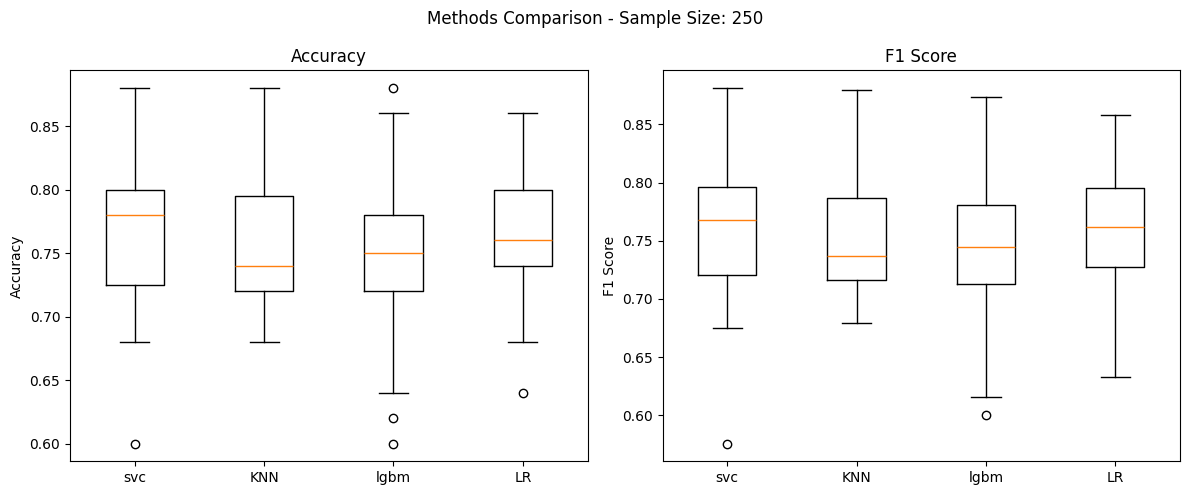


Evaluating with sample size: 500
Run 1/10, Fold 1/5, Method: svc, Accuracy: 0.8300, F1 Score: 0.8299, Time: 0.09 seconds
Run 1/10, Fold 1/5, Method: KNN, Accuracy: 0.8100, F1 Score: 0.8115, Time: 0.07 seconds
Run 1/10, Fold 1/5, Method: lgbm, Accuracy: 0.7600, F1 Score: 0.7579, Time: 0.98 seconds
Run 1/10, Fold 1/5, Method: LR, Accuracy: 0.8300, F1 Score: 0.8283, Time: 0.07 seconds
Run 1/10, Fold 2/5, Method: svc, Accuracy: 0.8500, F1 Score: 0.8472, Time: 0.09 seconds
Run 1/10, Fold 2/5, Method: KNN, Accuracy: 0.8600, F1 Score: 0.8584, Time: 0.07 seconds
Run 1/10, Fold 2/5, Method: lgbm, Accuracy: 0.7600, F1 Score: 0.7566, Time: 1.01 seconds
Run 1/10, Fold 2/5, Method: LR, Accuracy: 0.8200, F1 Score: 0.8174, Time: 0.07 seconds
Run 1/10, Fold 3/5, Method: svc, Accuracy: 0.7900, F1 Score: 0.7823, Time: 0.09 seconds
Run 1/10, Fold 3/5, Method: KNN, Accuracy: 0.8100, F1 Score: 0.8029, Time: 0.07 seconds
Run 1/10, Fold 3/5, Method: lgbm, Accuracy: 0.7500, F1 Score: 0.7441, Time: 0.99 secon

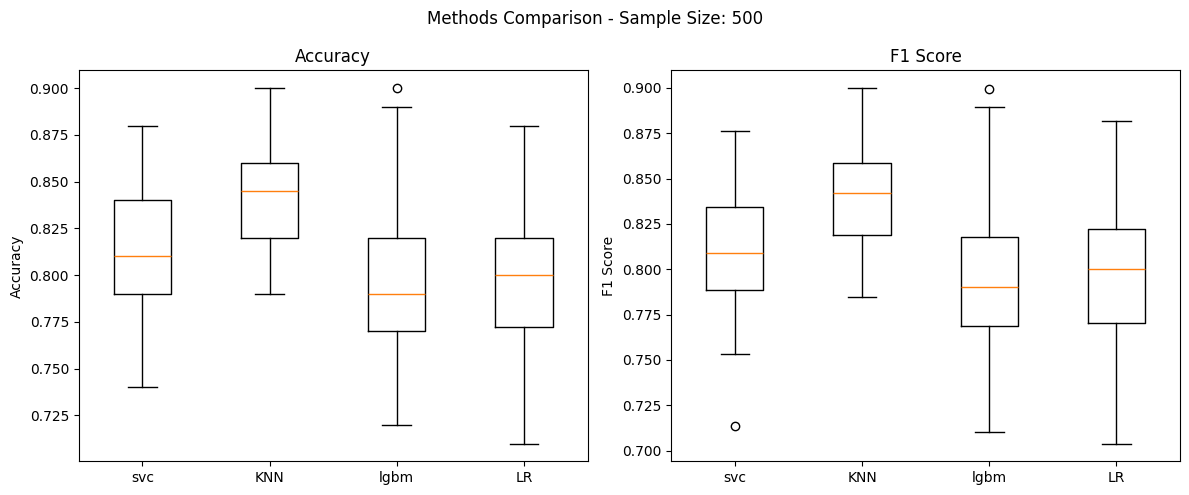


Evaluating with sample size: 1000
Run 1/10, Fold 1/5, Method: svc, Accuracy: 0.8450, F1 Score: 0.8447, Time: 0.11 seconds
Run 1/10, Fold 1/5, Method: KNN, Accuracy: 0.8850, F1 Score: 0.8840, Time: 0.09 seconds
Run 1/10, Fold 1/5, Method: lgbm, Accuracy: 0.8500, F1 Score: 0.8509, Time: 1.60 seconds
Run 1/10, Fold 1/5, Method: LR, Accuracy: 0.8600, F1 Score: 0.8599, Time: 0.10 seconds
Run 1/10, Fold 2/5, Method: svc, Accuracy: 0.8550, F1 Score: 0.8550, Time: 0.11 seconds
Run 1/10, Fold 2/5, Method: KNN, Accuracy: 0.8650, F1 Score: 0.8644, Time: 0.09 seconds
Run 1/10, Fold 2/5, Method: lgbm, Accuracy: 0.8750, F1 Score: 0.8745, Time: 1.64 seconds
Run 1/10, Fold 2/5, Method: LR, Accuracy: 0.8500, F1 Score: 0.8506, Time: 0.09 seconds
Run 1/10, Fold 3/5, Method: svc, Accuracy: 0.8600, F1 Score: 0.8549, Time: 0.11 seconds
Run 1/10, Fold 3/5, Method: KNN, Accuracy: 0.8650, F1 Score: 0.8614, Time: 0.09 seconds
Run 1/10, Fold 3/5, Method: lgbm, Accuracy: 0.8450, F1 Score: 0.8422, Time: 1.61 seco

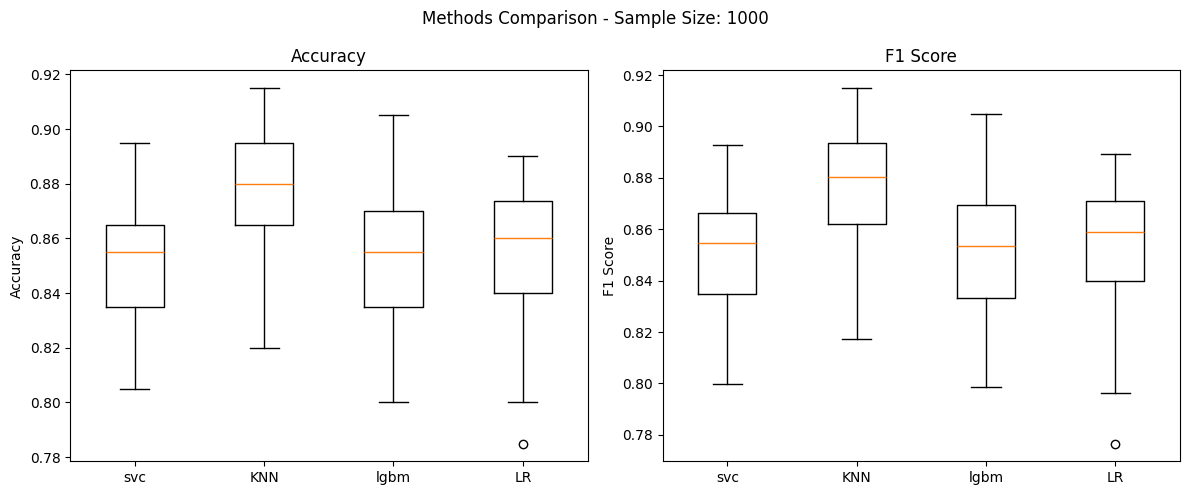

In [7]:
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.svm import LinearSVC
import warnings
warnings.filterwarnings('ignore', message='X does not have valid feature names')
methods = {
    'svc': 
    (Pipeline([
        ('scaler', StandardScaler()),
    ('svc', LinearSVC()),
    ]), {
        'svc__C': [0.1, 1.0, 10.0],
     }),
    'KNN':
    (Pipeline([
        ('clf', KNeighborsClassifier(n_jobs=-1)),
    ]), {'clf__n_neighbors': [3, 5, 11, 21]}),
    'lgbm':
    (Pipeline([
        ('clf', LGBMClassifier(n_estimators=100, num_leaves=15, random_state=0, verbosity=-1)),
    ]), {'clf__learning_rate': [0.01, 0.1]
         }),
    'LR':
    (Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, solver='lbfgs')),
    ]), {'clf__C': [0.01, 0.1, 1.0, 10.0]})
}


sample_sizes = [250, 500, 1000]
sample_accs = {}
sample_f1s = {}

for i, sample_size in enumerate(sample_sizes):
    print()
    print(f"Evaluating with sample size: {sample_size}")
    accs, f1s = evaluate_methods_with_outer_inner_cv(methods, images, labels, sample_size, outer_folds=5, inner_folds=3, number_of_times=10, seed=42)
    sample_accs[sample_size] = accs
    sample_f1s[sample_size] = f1s
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle(f"Methods Comparison - Sample Size: {sample_size}")
    ax = axes[0]
    ax.boxplot([accs[:, m] for m in range(len(methods))], tick_labels=methods.keys())
    ax.set_title("Accuracy")
    ax.set_ylabel("Accuracy")

    ax = axes[1]
    ax.boxplot([f1s[:, m] for m in range(len(methods))], tick_labels=methods.keys())
    ax.set_title("F1 Score")
    ax.set_ylabel("F1 Score")
    plt.tight_layout()
    plt.show()

Friedman statistic: 3.7965, p-value: 0.2843
No significant differences found among the methods.
Friedman statistic: 1.5451, p-value: 0.6719
No significant differences found among the methods.
Friedman statistic: 45.3057, p-value: 0.0000
Significant differences found. Performing pairwise post-hoc test

Pairwise Comparisons:
  svc                  vs KNN                 : p-value = 0.000019
  svc                  vs lgbm                : p-value = 0.007322
  svc                  vs LR                  : p-value = 0.001540
  KNN                  vs lgbm                : p-value = 0.000000
  KNN                  vs LR                  : p-value = 0.000001
  lgbm                 vs LR                  : p-value = 0.486921

Holm-Bonferroni Corrected p-values (Lower Triangular Matrix)

           svc           KNN      lgbm  LR
svc        NaN           NaN       NaN NaN
KNN   0.000076           NaN       NaN NaN
lgbm  0.014644  3.697919e-07       NaN NaN
LR    0.004621  2.703587e-06  0.486921

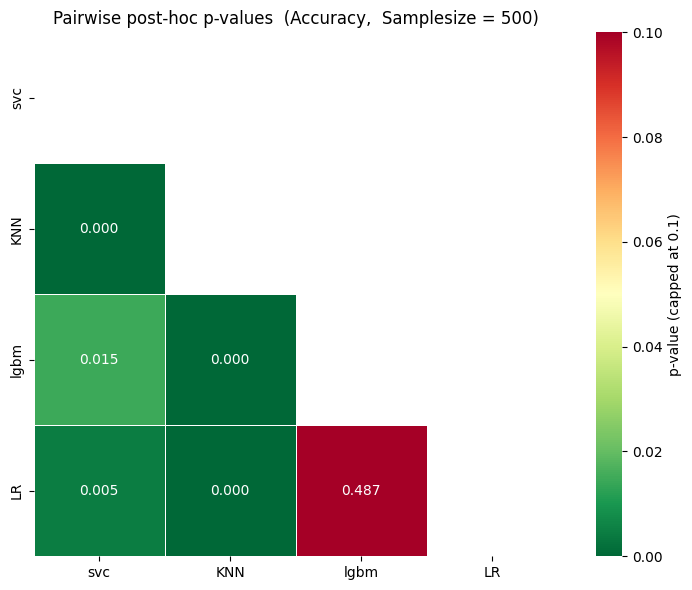

Friedman statistic: 43.0560, p-value: 0.0000
Significant differences found. Performing pairwise post-hoc test

Pairwise Comparisons:
  svc                  vs KNN                 : p-value = 0.000006
  svc                  vs lgbm                : p-value = 0.014079
  svc                  vs LR                  : p-value = 0.001236
  KNN                  vs lgbm                : p-value = 0.000000
  KNN                  vs LR                  : p-value = 0.000000
  lgbm                 vs LR                  : p-value = 0.527279

Holm-Bonferroni Corrected p-values (Lower Triangular Matrix)

           svc           KNN      lgbm  LR
svc        NaN           NaN       NaN NaN
KNN   0.000024           NaN       NaN NaN
lgbm  0.028157  1.400644e-08       NaN NaN
LR    0.003707  1.547001e-07  0.527279 NaN


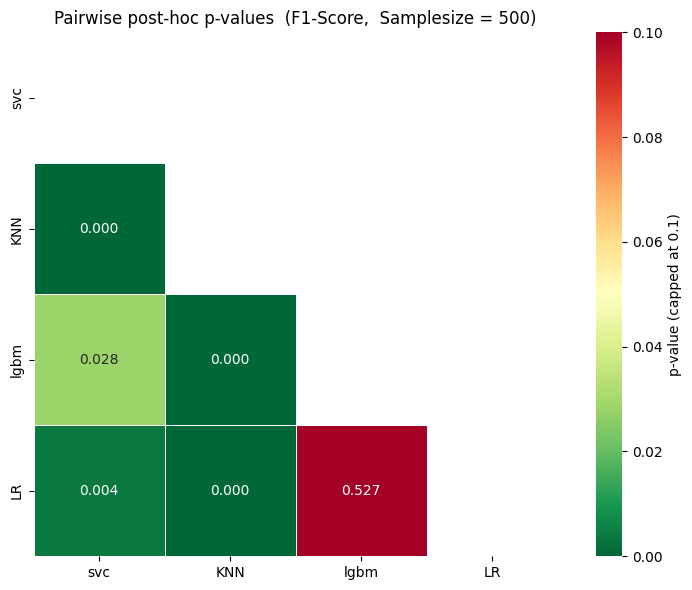

Friedman statistic: 41.2468, p-value: 0.0000
Significant differences found. Performing pairwise post-hoc test

Pairwise Comparisons:
  svc                  vs KNN                 : p-value = 0.000000
  svc                  vs lgbm                : p-value = 0.899634
  svc                  vs LR                  : p-value = 0.063223
  KNN                  vs lgbm                : p-value = 0.000000
  KNN                  vs LR                  : p-value = 0.000003
  lgbm                 vs LR                  : p-value = 0.289638

Holm-Bonferroni Corrected p-values (Lower Triangular Matrix)

               svc           KNN      lgbm  LR
svc            NaN           NaN       NaN NaN
KNN   5.608018e-07           NaN       NaN NaN
lgbm  8.996341e-01  6.206648e-07       NaN NaN
LR    1.896676e-01  1.183287e-05  0.579277 NaN


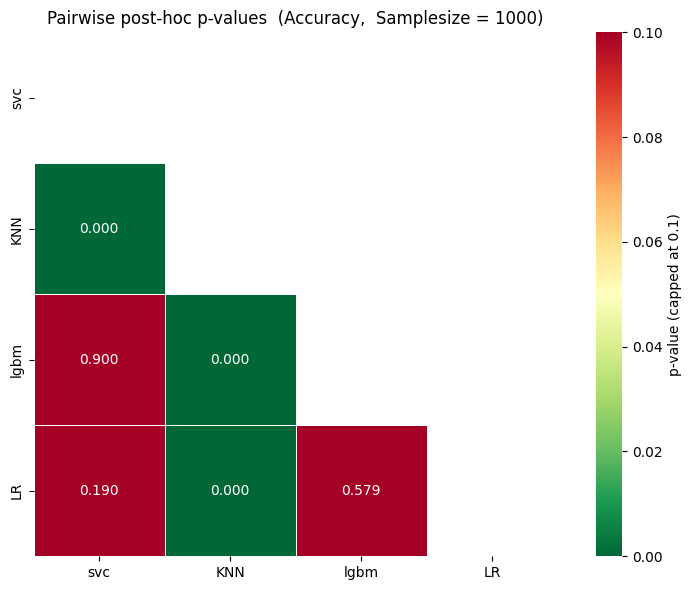

Friedman statistic: 44.2080, p-value: 0.0000
Significant differences found. Performing pairwise post-hoc test

Pairwise Comparisons:
  svc                  vs KNN                 : p-value = 0.000000
  svc                  vs lgbm                : p-value = 0.645876
  svc                  vs LR                  : p-value = 0.031262
  KNN                  vs lgbm                : p-value = 0.000000
  KNN                  vs LR                  : p-value = 0.000001
  lgbm                 vs LR                  : p-value = 0.269510

Holm-Bonferroni Corrected p-values (Lower Triangular Matrix)

               svc           KNN      lgbm  LR
svc            NaN           NaN       NaN NaN
KNN   7.889817e-09           NaN       NaN NaN
lgbm  6.458760e-01  1.406544e-08       NaN NaN
LR    9.378497e-02  3.745644e-06  0.539021 NaN


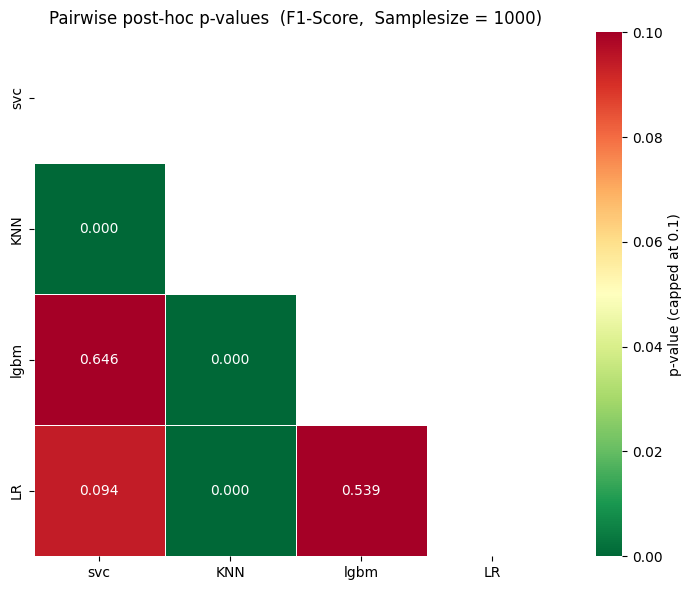

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import friedmanchisquare, rankdata
import scikit_posthocs as sp
from scipy.stats import wilcoxon
from itertools import combinations
from statsmodels.stats.multitest import multipletests
import numpy as np
import pandas as pd

def friedman(scores, method_names, sample_size, comparison_metric_name="Accuracy"):
    stat, pval = friedmanchisquare(*scores.T) 
    print(f"Friedman statistic: {stat:.4f}, p-value: {pval:.4f}")
    if pval > 0.05:
        print("No significant differences found among the methods.")
    else:
        print("Significant differences found. Performing pairwise post-hoc test")
        n_methods = scores.shape[1]
        method_names = list(method_names)
        pvals_raw = []
        comparisons = []

        print("\nPairwise Comparisons:")
        for i, j in combinations(range(n_methods), 2):
            stat, pval = wilcoxon(scores[:, i], scores[:, j])
            pvals_raw.append(pval)
            comparisons.append((method_names[i], method_names[j]))
            print(f"  {method_names[i]:20s} vs {method_names[j]:20s}: p-value = {pval:.6f}")
        pvals_raw = np.array(pvals_raw)
        reject, pvals_corrected, _, _ = multipletests(pvals_raw, method='holm')

        p_matrix = pd.DataFrame(np.full((n_methods, n_methods), np.nan), 
                                index=method_names, 
                                columns=method_names)

        idx_counter = 0
        for i, j in combinations(range(n_methods), 2):
            p_matrix.iloc[j, i] = pvals_corrected[idx_counter]
            idx_counter += 1

        print("\n" + "=" * 70)
        print("Holm-Bonferroni Corrected p-values (Lower Triangular Matrix)")
        print("=" * 70)
        print("\n" + p_matrix.to_string())
        fig, ax = plt.subplots(figsize=(8, 6))
        sns.heatmap(p_matrix, annot=True, fmt='.3f', cmap='RdYlGn_r',
                    vmin=0, vmax=0.1, cbar_kws={'label': 'p-value (capped at 0.1)'},
                    ax=ax, square=True, linewidths=0.5)
        plt.title(f'Pairwise post-hoc p-values  ({comparison_metric_name},  Samplesize = {sample_size})')
        plt.tight_layout()
        plt.show()


for sample_size in sample_sizes:
    friedman(sample_accs[sample_size], list(methods.keys()), sample_size=sample_size, comparison_metric_name="Accuracy")
    friedman(sample_f1s[sample_size], list(methods.keys()), sample_size=sample_size, comparison_metric_name="F1-Score")
    

## Part 2 - Themes
You will be allocated one of the three themes and should perform ***all*** tasks as described in this theme.

### Theme 1 - Imbalance
Use the Cats and Dogs dataset.

Investigate the effects of imbalance on PART 1 - where you create the imbalance. Try with different train, calibration and test sizes. 

Does the model ranking change?

### Theme 2 - Conformal Prediction
Use the MNIST data set.

Select 3 classifiers. Perform conformal prediction. Do you observe similar conformal predictions between the methods? Summarize the conformal predictions. Are certain classes more often to be lumped together in the same set of predictions and does it depend on the classifier used? 

Try with different train, calibration and test sizes. 

### Theme 3 - Mislabeling

Create a mislabeled data set from the digits data by randomly changing the labels for some of the observations. *Note, you should only create mislabels for your training data - the test data should be clean.*

Redo Part 1 in this setting.

Which methods handle the mislabeling OK? Which methods struggle? How does sample size affect this?

You should explore at least 3 levels of mislabeling (some modest, some more severe and some really severe cases), i.e. proportion of mislabeled data. *Please note that your test data should be "clean", i.e. without mislabeling*. For each simulation run, make sure you create a clean and separate data set to estimate prediction performance.

Do the above on 3 levels of data (full data, medium data, small data).

In [10]:
# ...then the numbers data
import pandas as pd

PATHIM = "mnist_large//images.csv"
PATHLB = "mnist_large//labels.csv"

images = pd.read_csv(PATHIM, sep=",", index_col=0)
labels = pd.read_csv(PATHLB, sep=",", index_col=0)

labels = labels.rename(columns={"0":"label"})

# Check sizes
print(f"'images' size: {images.shape}")
print(f"'labels' size: {labels.shape}")

# Number of classes:
print(f"Classes {labels['label'].unique()}")

'images' size: (10000, 784)
'labels' size: (10000, 1)
Classes [0 1 2 3 4 5 6 7 8 9]


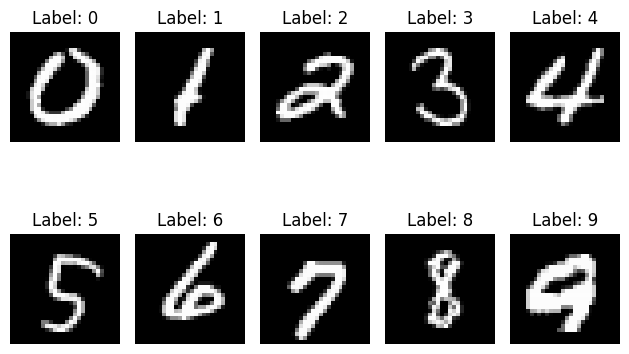

In [11]:
import matplotlib.pyplot as plt
import numpy as np

images = np.array(images)
labels = np.array(labels).ravel()

n_images = images.shape[0]

# Visualize the first images in each class
idx = [np.where(labels == i)[0][0] for i in range(10)]
images_sub = images[idx]
labels_sub = labels[idx]

fig, axes = plt.subplots(2, 5)

for i, ax in enumerate(axes.ravel()):
    img = images_sub[i].reshape(28,28)
    ax.imshow(img, cmap="gray")
    ax.set_title(f"Label: {labels_sub[i]}")
    ax.axis("off")

plt.tight_layout()

In [12]:
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import accuracy_score, f1_score
import numpy as np
from sklearn.model_selection import StratifiedKFold, GridSearchCV, train_test_split
from sklearn.metrics import accuracy_score, f1_score
import time
from sklearn.feature_selection import VarianceThreshold


def evaluate_methods_with_outer_inner_cv_with_misslabels(methods, X, y, sample_size, outer_folds, inner_folds, miss_label_rate=0.1, number_of_times=3, seed=42):
    if sample_size < len(y):
        X_sample, _, y_sample, _ = train_test_split(X, y, train_size=sample_size, stratify=y, random_state=seed)
    else:
        X_sample, y_sample = X, y
    f1_scores = np.zeros((number_of_times*outer_folds, len(methods)))
    acc_scores = np.zeros((number_of_times*outer_folds, len(methods)))
    for run in range(number_of_times):
        run_seed = seed + run
        np.random.seed(run_seed)
        outer_cv = StratifiedKFold(n_splits=outer_folds, shuffle=True, random_state=run_seed)
        for k, (train_idx, test_idx) in enumerate(outer_cv.split(X_sample, y_sample)):
            X_train, X_test = X_sample[train_idx], X_sample[test_idx]
            y_train, y_test = y_sample[train_idx], y_sample[test_idx]
            n_misslabels = int(miss_label_rate * len(y_train))
            misslabel_indices = np.random.choice(np.arange(len(y_train)), size=n_misslabels, replace=False)
            classes = np.unique(y_train)
            for idx in misslabel_indices:
                other_classes = classes[classes != y_train[idx]]
                y_train[idx] = np.random.choice(other_classes)
            inner_cv = StratifiedKFold(n_splits=inner_folds, shuffle=True, random_state=run_seed + 42) # Adding 42 because it might hurt if same seed as outer

            X_train = X_train.copy()
            X_test = X_test.copy()
            pca = PCA(random_state=0, n_components=35)
            X_train = pca.fit_transform(X_train)
            X_test = pca.transform(X_test)
            for m, method in enumerate(methods):
                pipeline, params = methods[method]
                t0 = time.time()
                grid_search = GridSearchCV(estimator=pipeline, param_grid=params, cv=inner_cv, scoring='accuracy')
                grid_search.fit(X_train, y_train)
                y_pred = grid_search.predict(X_test)
                acc = accuracy_score(y_test, y_pred)
                f1 = f1_score(y_test, y_pred, average='macro')
                acc_scores[run*outer_folds + k, m] = acc
                f1_scores[run*outer_folds + k, m] = f1
                print(f"Run {run+1}/{number_of_times}, Fold {k+1}/{outer_folds}, Method: {method}, Accuracy: {acc:.4f}, F1 Score: {f1:.4f}, Time: {time.time() - t0:.2f} seconds")
    return acc_scores, f1_scores



Evaluating with sample size: 10000
Run 1/10, Fold 1/5, Method: svc, Accuracy: 0.8570, F1 Score: 0.8556, Time: 0.59 seconds
Run 1/10, Fold 1/5, Method: KNN, Accuracy: 0.9500, F1 Score: 0.9499, Time: 0.29 seconds
Run 1/10, Fold 1/5, Method: lgbm, Accuracy: 0.9150, F1 Score: 0.9147, Time: 3.31 seconds
Run 1/10, Fold 1/5, Method: LR, Accuracy: 0.8700, F1 Score: 0.8695, Time: 0.33 seconds
Run 1/10, Fold 2/5, Method: svc, Accuracy: 0.8710, F1 Score: 0.8697, Time: 0.52 seconds
Run 1/10, Fold 2/5, Method: KNN, Accuracy: 0.9625, F1 Score: 0.9625, Time: 0.26 seconds
Run 1/10, Fold 2/5, Method: lgbm, Accuracy: 0.9235, F1 Score: 0.9235, Time: 3.27 seconds
Run 1/10, Fold 2/5, Method: LR, Accuracy: 0.8885, F1 Score: 0.8880, Time: 0.35 seconds
Run 1/10, Fold 3/5, Method: svc, Accuracy: 0.8600, F1 Score: 0.8585, Time: 0.51 seconds
Run 1/10, Fold 3/5, Method: KNN, Accuracy: 0.9520, F1 Score: 0.9519, Time: 0.25 seconds
Run 1/10, Fold 3/5, Method: lgbm, Accuracy: 0.9145, F1 Score: 0.9144, Time: 3.33 sec

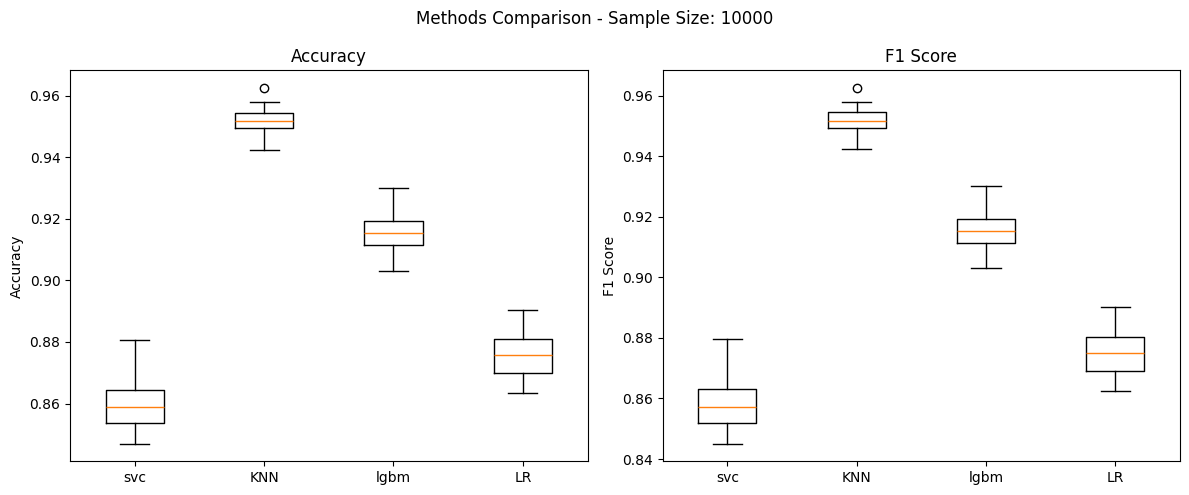


Evaluating with sample size: 1000
Run 1/10, Fold 1/5, Method: svc, Accuracy: 0.8400, F1 Score: 0.8400, Time: 0.09 seconds
Run 1/10, Fold 1/5, Method: KNN, Accuracy: 0.8550, F1 Score: 0.8551, Time: 0.10 seconds
Run 1/10, Fold 1/5, Method: lgbm, Accuracy: 0.8350, F1 Score: 0.8363, Time: 1.74 seconds
Run 1/10, Fold 1/5, Method: LR, Accuracy: 0.8250, F1 Score: 0.8260, Time: 0.11 seconds
Run 1/10, Fold 2/5, Method: svc, Accuracy: 0.8200, F1 Score: 0.8204, Time: 0.09 seconds
Run 1/10, Fold 2/5, Method: KNN, Accuracy: 0.8700, F1 Score: 0.8694, Time: 0.11 seconds
Run 1/10, Fold 2/5, Method: lgbm, Accuracy: 0.8600, F1 Score: 0.8599, Time: 1.73 seconds
Run 1/10, Fold 2/5, Method: LR, Accuracy: 0.8400, F1 Score: 0.8413, Time: 0.11 seconds
Run 1/10, Fold 3/5, Method: svc, Accuracy: 0.8400, F1 Score: 0.8339, Time: 0.09 seconds
Run 1/10, Fold 3/5, Method: KNN, Accuracy: 0.8700, F1 Score: 0.8678, Time: 0.10 seconds
Run 1/10, Fold 3/5, Method: lgbm, Accuracy: 0.8350, F1 Score: 0.8328, Time: 1.71 seco

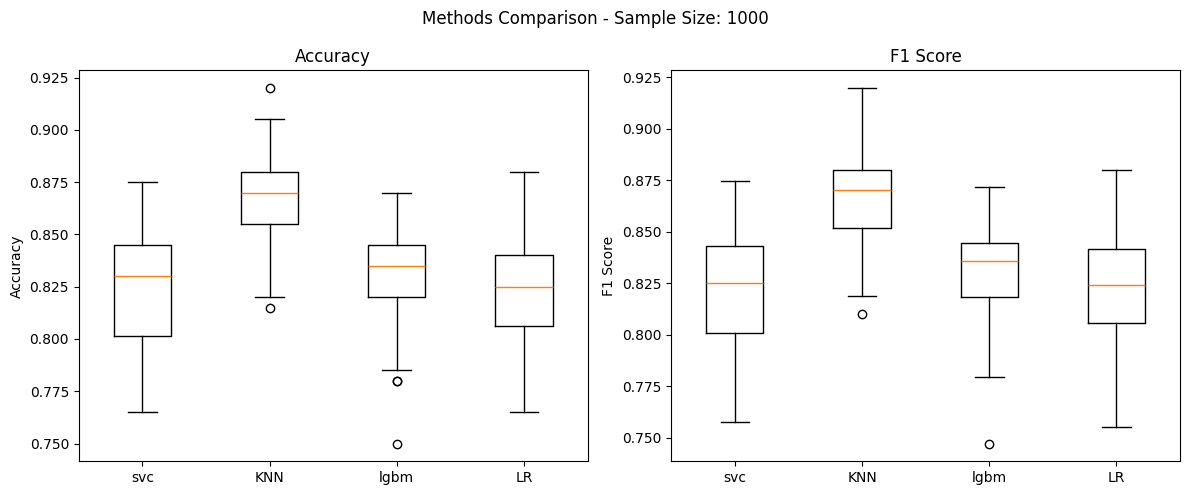


Evaluating with sample size: 100
Run 1/10, Fold 1/5, Method: svc, Accuracy: 0.6500, F1 Score: 0.6167, Time: 0.08 seconds
Run 1/10, Fold 1/5, Method: KNN, Accuracy: 0.6000, F1 Score: 0.5267, Time: 0.06 seconds
Run 1/10, Fold 1/5, Method: lgbm, Accuracy: 0.4500, F1 Score: 0.4300, Time: 0.27 seconds
Run 1/10, Fold 1/5, Method: LR, Accuracy: 0.6000, F1 Score: 0.5852, Time: 0.06 seconds
Run 1/10, Fold 2/5, Method: svc, Accuracy: 0.5000, F1 Score: 0.4143, Time: 0.08 seconds
Run 1/10, Fold 2/5, Method: KNN, Accuracy: 0.3000, F1 Score: 0.1967, Time: 0.06 seconds
Run 1/10, Fold 2/5, Method: lgbm, Accuracy: 0.5000, F1 Score: 0.4000, Time: 0.26 seconds
Run 1/10, Fold 2/5, Method: LR, Accuracy: 0.5000, F1 Score: 0.4371, Time: 0.06 seconds
Run 1/10, Fold 3/5, Method: svc, Accuracy: 0.5500, F1 Score: 0.5333, Time: 0.09 seconds
Run 1/10, Fold 3/5, Method: KNN, Accuracy: 0.4000, F1 Score: 0.3305, Time: 0.06 seconds
Run 1/10, Fold 3/5, Method: lgbm, Accuracy: 0.6000, F1 Score: 0.5767, Time: 0.27 secon

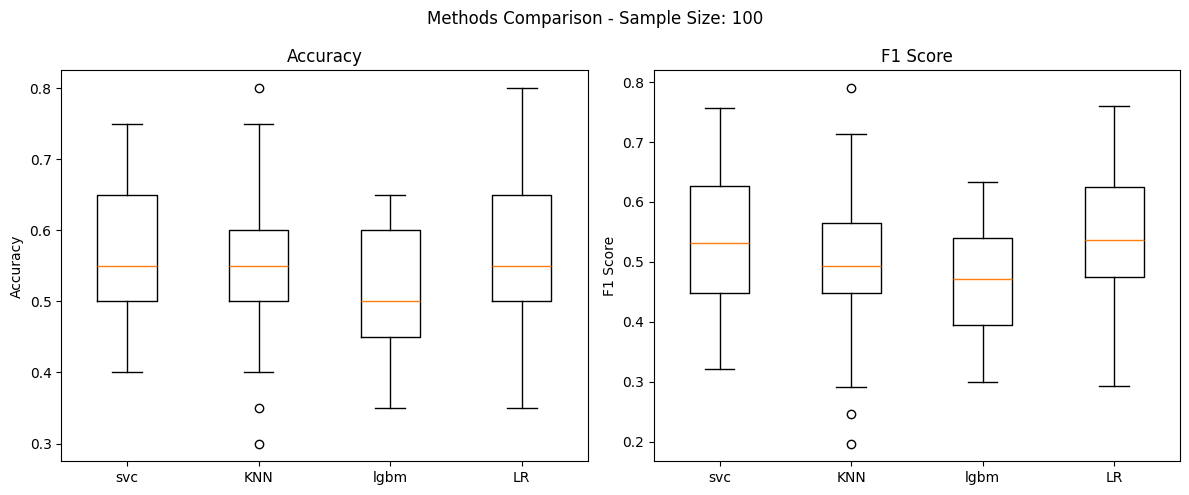

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.svm import LinearSVC
import warnings
warnings.filterwarnings('ignore', message='X does not have valid feature names')
methods = {
    'svc': 
    (Pipeline([
        ('scaler', StandardScaler()),
    ('svc', LinearSVC()),
    ]), {
        'svc__C': [0.1, 1.0, 10.0],
     }),
    'KNN':
    (Pipeline([
        ('clf', KNeighborsClassifier(n_jobs=-1)),
    ]), {'clf__n_neighbors': [3, 5, 11, 21]}),
    'lgbm':
    (Pipeline([
        ('clf', LGBMClassifier(n_estimators=100, num_leaves=15, random_state=0, verbosity=-1)),
    ]), {'clf__learning_rate': [0.01, 0.1]
         }),
    'LR':
    (Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, solver='lbfgs')),
    ]), {'clf__C': [0.01, 0.1, 1.0, 10.0]})
}


sample_sizes = [len(images), len(images)//10, len(images)//100]
sample_accs = {}
sample_f1s = {}
miss_label_rate = 0.3 # Modify this to run with different misslabel rates

for i, sample_size in enumerate(sample_sizes):
    print()
    print(f"Evaluating with sample size: {sample_size}")
    accs, f1s = evaluate_methods_with_outer_inner_cv_with_misslabels(methods, images, labels, sample_size, outer_folds=5, inner_folds=3, miss_label_rate=miss_label_rate, number_of_times=10, seed=42)
    sample_accs[sample_size] = accs
    sample_f1s[sample_size] = f1s
    # plot boxplots
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle(f"Methods Comparison - Sample Size: {sample_size}")
    ax = axes[0]
    ax.boxplot([accs[:, m] for m in range(len(methods))], tick_labels=methods.keys())
    ax.set_title("Accuracy")
    ax.set_ylabel("Accuracy")

    ax = axes[1]
    ax.boxplot([f1s[:, m] for m in range(len(methods))], tick_labels=methods.keys())
    ax.set_title("F1 Score")
    ax.set_ylabel("F1 Score")
    plt.tight_layout()
    plt.show()

Friedman statistic: 150.0000, p-value: 0.0000
Significant differences found. Performing pairwise post-hoc test

Pairwise Comparisons:
  svc                  vs KNN                 : p-value = 0.000000
  svc                  vs lgbm                : p-value = 0.000000
  svc                  vs LR                  : p-value = 0.000000
  KNN                  vs lgbm                : p-value = 0.000000
  KNN                  vs LR                  : p-value = 0.000000
  lgbm                 vs LR                  : p-value = 0.000000

Holm-Bonferroni Corrected p-values (Lower Triangular Matrix)

               svc           KNN          lgbm  LR
svc            NaN           NaN           NaN NaN
KNN   4.467954e-09           NaN           NaN NaN
lgbm  4.467954e-09  4.467954e-09           NaN NaN
LR    4.467954e-09  4.467954e-09  4.467954e-09 NaN


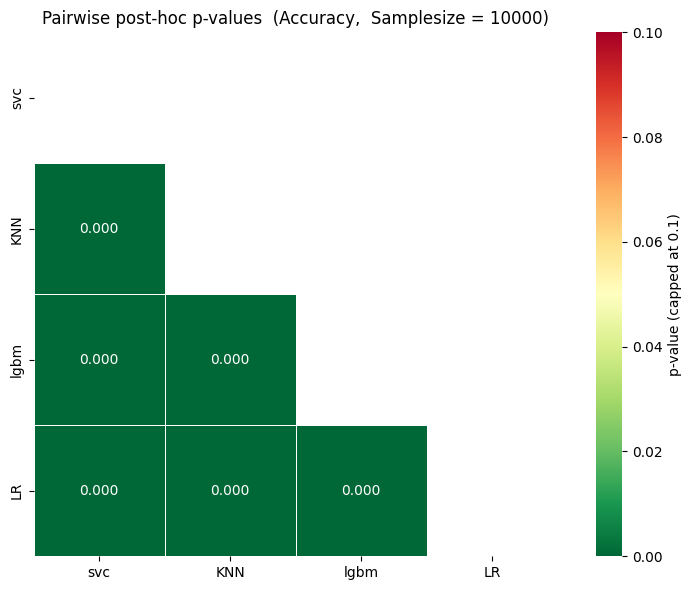

Friedman statistic: 150.0000, p-value: 0.0000
Significant differences found. Performing pairwise post-hoc test

Pairwise Comparisons:
  svc                  vs KNN                 : p-value = 0.000000
  svc                  vs lgbm                : p-value = 0.000000
  svc                  vs LR                  : p-value = 0.000000
  KNN                  vs lgbm                : p-value = 0.000000
  KNN                  vs LR                  : p-value = 0.000000
  lgbm                 vs LR                  : p-value = 0.000000

Holm-Bonferroni Corrected p-values (Lower Triangular Matrix)

               svc           KNN          lgbm  LR
svc            NaN           NaN           NaN NaN
KNN   1.065814e-14           NaN           NaN NaN
lgbm  1.065814e-14  1.065814e-14           NaN NaN
LR    1.065814e-14  1.065814e-14  1.065814e-14 NaN


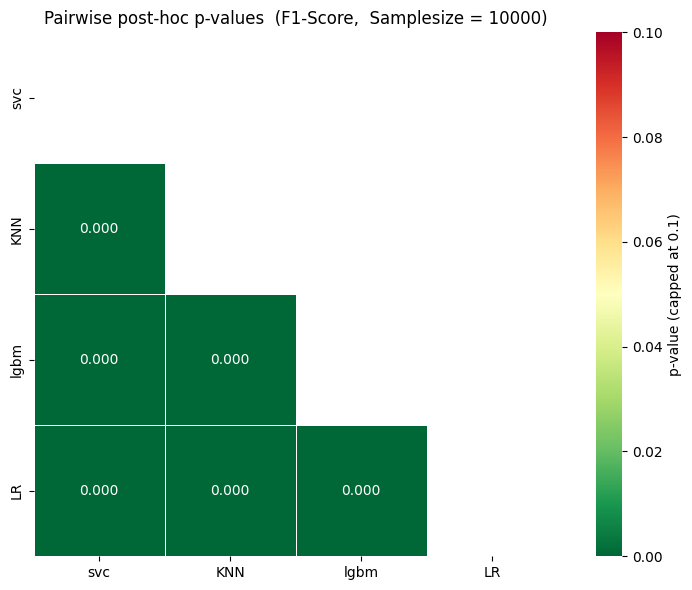

Friedman statistic: 67.9568, p-value: 0.0000
Significant differences found. Performing pairwise post-hoc test

Pairwise Comparisons:
  svc                  vs KNN                 : p-value = 0.000000
  svc                  vs lgbm                : p-value = 0.172404
  svc                  vs LR                  : p-value = 0.803414
  KNN                  vs lgbm                : p-value = 0.000000
  KNN                  vs LR                  : p-value = 0.000000
  lgbm                 vs LR                  : p-value = 0.143394

Holm-Bonferroni Corrected p-values (Lower Triangular Matrix)

               svc           KNN      lgbm  LR
svc            NaN           NaN       NaN NaN
KNN   4.442725e-08           NaN       NaN NaN
lgbm  4.301807e-01  2.647723e-08       NaN NaN
LR    8.034142e-01  4.442725e-08  0.430181 NaN


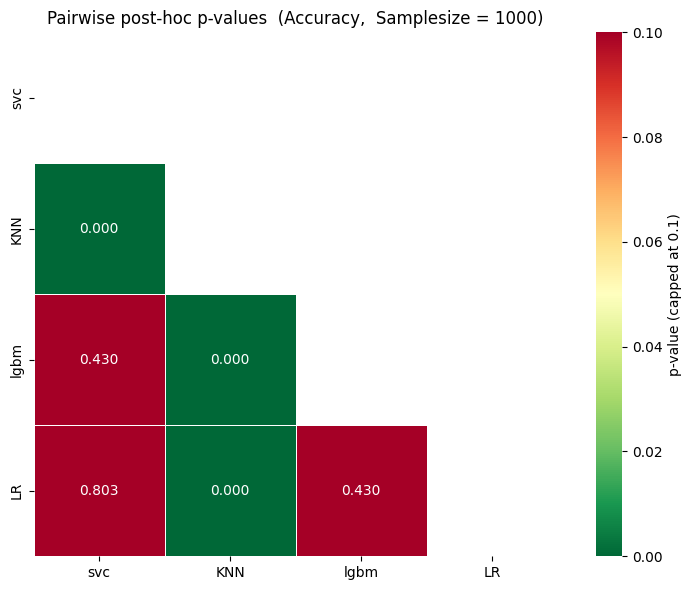

Friedman statistic: 66.6960, p-value: 0.0000
Significant differences found. Performing pairwise post-hoc test

Pairwise Comparisons:
  svc                  vs KNN                 : p-value = 0.000000
  svc                  vs lgbm                : p-value = 0.097094
  svc                  vs LR                  : p-value = 0.954225
  KNN                  vs lgbm                : p-value = 0.000000
  KNN                  vs LR                  : p-value = 0.000000
  lgbm                 vs LR                  : p-value = 0.082268

Holm-Bonferroni Corrected p-values (Lower Triangular Matrix)

               svc           KNN      lgbm  LR
svc            NaN           NaN       NaN NaN
KNN   7.724488e-11           NaN       NaN NaN
lgbm  2.468026e-01  2.168932e-11       NaN NaN
LR    9.542250e-01  1.052243e-10  0.246803 NaN


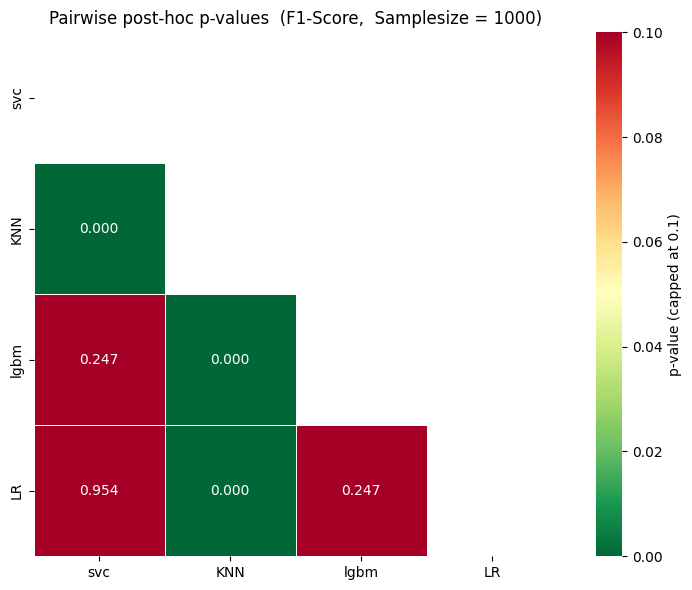

Friedman statistic: 24.4203, p-value: 0.0000
Significant differences found. Performing pairwise post-hoc test

Pairwise Comparisons:
  svc                  vs KNN                 : p-value = 0.231647
  svc                  vs lgbm                : p-value = 0.000050
  svc                  vs LR                  : p-value = 0.608093
  KNN                  vs lgbm                : p-value = 0.005180
  KNN                  vs LR                  : p-value = 0.096166
  lgbm                 vs LR                  : p-value = 0.000030

Holm-Bonferroni Corrected p-values (Lower Triangular Matrix)

           svc       KNN      lgbm  LR
svc        NaN       NaN       NaN NaN
KNN   0.463295       NaN       NaN NaN
lgbm  0.000252  0.020719       NaN NaN
LR    0.608093  0.288497  0.000178 NaN


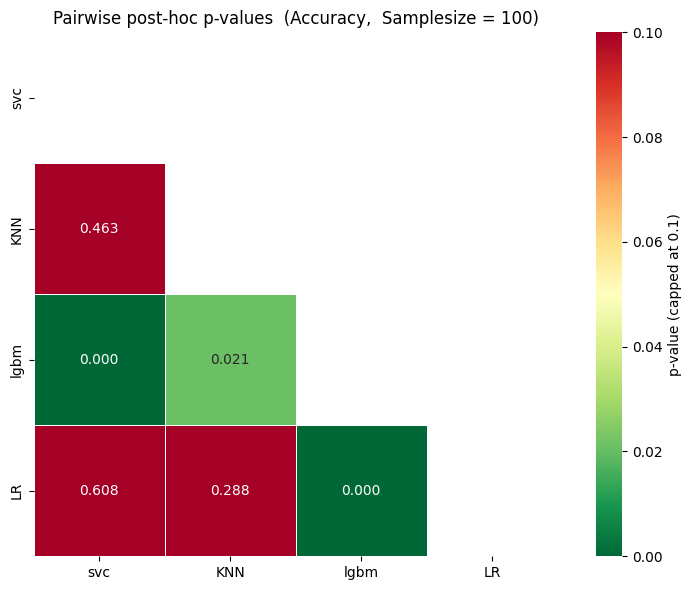

Friedman statistic: 18.8641, p-value: 0.0003
Significant differences found. Performing pairwise post-hoc test

Pairwise Comparisons:
  svc                  vs KNN                 : p-value = 0.006919
  svc                  vs lgbm                : p-value = 0.000125
  svc                  vs LR                  : p-value = 0.803877
  KNN                  vs lgbm                : p-value = 0.064514
  KNN                  vs LR                  : p-value = 0.001457
  lgbm                 vs LR                  : p-value = 0.000042

Holm-Bonferroni Corrected p-values (Lower Triangular Matrix)

           svc       KNN     lgbm  LR
svc        NaN       NaN      NaN NaN
KNN   0.020757       NaN      NaN NaN
lgbm  0.000623  0.129027      NaN NaN
LR    0.803877  0.005827  0.00025 NaN


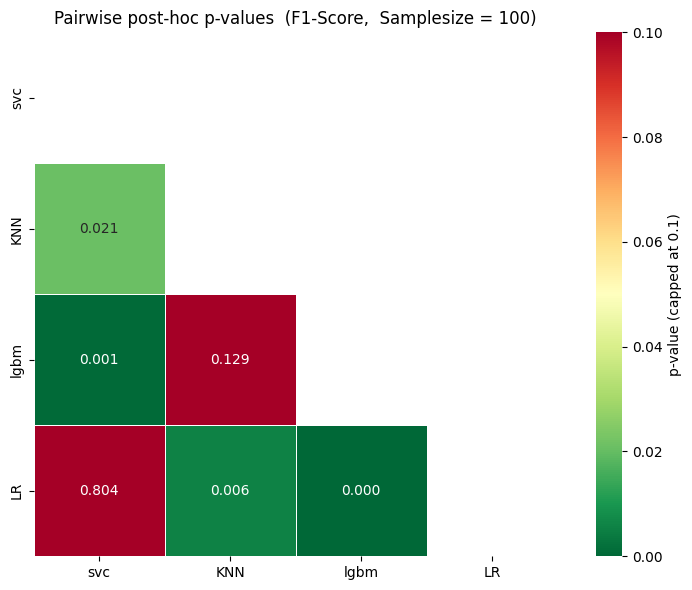

In [14]:
for sample_size in sample_sizes:
    friedman(sample_accs[sample_size], list(methods.keys()), sample_size=sample_size, comparison_metric_name="Accuracy")
    friedman(sample_f1s[sample_size], list(methods.keys()), sample_size=sample_size, comparison_metric_name="F1-Score")